# 01: Variable-Length preprocessing for `old` + `nm`

- `old`: trial/on-paper logic from original script (no fixed-length resample)
- `nm`: digit events with `duration` window, clipped by 1-99% quantiles, then only 2000->1000 resample


In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# outputs remain inside code_bobr_678
NOTEBOOK_DIR = Path.cwd().resolve()
if not (NOTEBOOK_DIR / '01_preprocess_nm000106.ipynb').exists():
    alt = NOTEBOOK_DIR / 'data' / 'preprocessing'
    if (alt / '01_preprocess_nm000106.ipynb').exists():
        NOTEBOOK_DIR = alt
DATA_ROOT = (NOTEBOOK_DIR / '..').resolve()
PROJECT_ROOT = DATA_ROOT.parent

# --- project-relative raw paths ---
RAW_ROOT = DATA_ROOT / 'raw'
NM_ROOT = RAW_ROOT / 'nm000106-main'
OLD_ROOT = RAW_ROOT / 'data_8ch_EMG'
OLD_META = RAW_ROOT / 'dataset_metadata.json'

SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from nm_loader import (
    discover_sessions,
    read_events,
    filter_digit_prompts,
    build_nm_variable_windows,
    build_old_variable_windows,
    pack_variable_length_trials,
    save_variable_length_npz,
    apply_channel_variant_packed,
    summarize_lengths,
)
ART_DATA = DATA_ROOT / 'datasets'
ART_REP = PROJECT_ROOT / 'reports' / 'artifacts' / 'preprocessing'
ART_DATA.mkdir(parents=True, exist_ok=True)
ART_REP.mkdir(parents=True, exist_ok=True)

print('NM_ROOT:', NM_ROOT)
print('OLD_ROOT:', OLD_ROOT)
print('OLD_META:', OLD_META)
print('ART_DATA:', ART_DATA)
print('ART_REP:', ART_REP)


NM_ROOT: nm000106-main
OLD_ROOT: data_8ch_EMG
OLD_META: code_anna/emg_handwriting-main/emg_handwriting-main/dataset_metadata.json


In [2]:
sessions = discover_sessions(NM_ROOT)
print('sessions discovered:', len(sessions))

events0 = read_events(sessions[0].events_tsv)
digits0 = filter_digit_prompts(events0)
print('session[0] events:', len(events0), 'digit prompts:', len(digits0))
print('sample digit prompts:', [e['prompt_text'] for e in digits0[:10]])
assert all(len(str(e['prompt_text'])) == 1 and str(e['prompt_text']).isdigit() for e in digits0)


sessions discovered: 807
session[0] events: 119 digit prompts: 10
sample digit prompts: ['9', '1', '5', '6', '0', '2', '8', '7', '3', '4']


In [3]:
print('Old dataset crop rule: strictly OnPaper-only.')

old_var = build_old_variable_windows(
    OLD_ROOT,
    OLD_META,
    sfreq_hz=1000,
    verbose=True,
)

nm_var = build_nm_variable_windows(
    NM_ROOT,
    source_sfreq_hz=2000,
    target_sfreq_hz=1000,
    duration_q_low=0.01,
    duration_q_high=0.99,
    verbose=True,
)

print('old windows:', len(old_var['emg_list']))
print('nm windows:', len(nm_var['emg_list']))
print('old length stats:', old_var['meta']['length_stats'])
print('nm length stats:', nm_var['meta']['length_stats'])


Old dataset crop rule: strictly OnPaper-only.
[001/011] export1_13Nov07.mat (J) | trials: 499
[002/011] export1_15Nov07.mat (S) | trials: 450
[003/011] export1_30Nov07.mat (C) | trials: 469
[004/011] export1_19Dec07.mat (M1) | trials: 477
[005/011] export1_20Dec07.mat (B) | trials: 491
[006/011] export1_21Dec07.mat (A) | trials: 492
[007/011] export1_2Jan08.mat (M2) | trials: 491
[008/011] export1_3Jan08.mat (M3) | trials: 518
[009/011] export1_7Jan08.mat (M4) | trials: 549
[010/011] export1_15Jan08.mat (M5) | trials: 550
[011/011] export1_24Jan08.mat (M6) | trials: 555
[0001/0807] sub-000 ses-000 | digit events: 10
[0002/0807] sub-000 ses-001 | digit events: 10
[0003/0807] sub-000 ses-002 | digit events: 10
[0004/0807] sub-000 ses-003 | digit events: 10
[0005/0807] sub-001 ses-000 | digit events: 10
[0006/0807] sub-001 ses-001 | digit events: 10
[0007/0807] sub-001 ses-002 | digit events: 10
[0008/0807] sub-001 ses-003 | digit events: 10
[0009/0807] sub-001 ses-004 | digit events: 10


In [4]:
old_packed = pack_variable_length_trials(
    old_var['emg_list'],
    old_var['target'],
    old_var['subject'],
    channels=old_var['channels'],
)

nm16_packed = pack_variable_length_trials(
    nm_var['emg_list'],
    nm_var['target'],
    nm_var['subject'],
    session=nm_var['session'],
    channels=nm_var['channels'],
)

def select_channels_by_pca(packed, k=8, random_state=42):
    x = packed['emg_concat']
    x_scaled = StandardScaler().fit_transform(x)

    pca = PCA(n_components=min(k, x_scaled.shape[1]), random_state=random_state)
    pca.fit(x_scaled)

    # Importance of each original channel in top-k components.
    weighted_loadings = np.abs(pca.components_) * pca.explained_variance_ratio_[:, None]
    channel_scores = weighted_loadings.sum(axis=0)
    idx = np.argsort(channel_scores)[-k:]
    return np.sort(idx.astype(int))

idx8 = select_channels_by_pca(nm16_packed, k=8, random_state=42)
nm8_packed, nm8_info = apply_channel_variant_packed(
    nm16_packed,
    '8-selected',
    selected_channels=idx8,
)

OLD_NPZ = ART_DATA / 'old_digits_varlen_8ch.npz'
NM16_NPZ = ART_DATA / 'nm_digits_varlen_16ch.npz'
NM8_NPZ = ART_DATA / 'nm_digits_varlen_8selected.npz'

save_variable_length_npz(
    OLD_NPZ,
    old_packed,
    metadata={
        **old_var['meta'],
        'format': 'varlen_npz',
        'length_stats_packed': summarize_lengths(old_packed['lengths']),
    },
)
save_variable_length_npz(
    NM16_NPZ,
    nm16_packed,
    metadata={
        **nm_var['meta'],
        'format': 'varlen_npz',
        'channel_variant': '16-channel',
        'length_stats_packed': summarize_lengths(nm16_packed['lengths']),
    },
)
save_variable_length_npz(
    NM8_NPZ,
    nm8_packed,
    metadata={
        **nm_var['meta'],
        'format': 'varlen_npz',
        'channel_variant': '8-selected',
        'selected_channels': idx8.tolist(),
        'length_stats_packed': summarize_lengths(nm8_packed['lengths']),
    },
)

print('saved:', OLD_NPZ)
print('saved:', NM16_NPZ)
print('saved:', NM8_NPZ)
print('8-selected channels:', idx8.tolist())


saved: code_bobr_678/data/datasets/old_digits_varlen_8ch.npz
saved: code_bobr_678/data/datasets/nm_digits_varlen_16ch.npz
saved: code_bobr_678/data/datasets/nm_digits_varlen_8selected.npz
8-selected channels: [1, 5, 6, 7, 9, 10, 13, 15]


In [5]:
for name, packed in [('old', old_packed), ('nm16', nm16_packed), ('nm8', nm8_packed)]:
    n = len(packed['target'])
    assert len(packed['subject']) == n
    assert len(packed['lengths']) == n
    assert len(packed['offsets']) == n + 1
    assert packed['offsets'][0] == 0
    assert packed['offsets'][-1] == len(packed['emg_concat'])
    assert np.isfinite(packed['emg_concat']).all(), f'{name}: NaN/Inf in EMG'
    assert set(np.unique(packed['target']).tolist()).issubset(set(range(10))), f'{name}: target out of 0..9'
    print(name, 'OK | N=', n, 'C=', packed['emg_concat'].shape[1], 'len_stats=', summarize_lengths(packed['lengths']))


old OK | N= 5534 C= 8 len_stats= {'n': 5534.0, 'min': 328.0, 'max': 9203.0, 'mean': 1924.8879653053848, 'median': 1875.0, 'q01': 517.0, 'q05': 718.0, 'q95': 3251.0, 'q99': 4110.0}
nm16 OK | N= 7018 C= 16 len_stats= {'n': 7018.0, 'min': 740.0, 'max': 23360.0, 'mean': 2024.880022798518, 'median': 1411.0, 'q01': 740.0, 'q05': 878.0, 'q95': 3261.199999999997, 'q99': 23352.179999999997}
nm8 OK | N= 7018 C= 8 len_stats= {'n': 7018.0, 'min': 740.0, 'max': 23360.0, 'mean': 2024.880022798518, 'median': 1411.0, 'q01': 740.0, 'q05': 878.0, 'q95': 3261.199999999997, 'q99': 23352.179999999997}


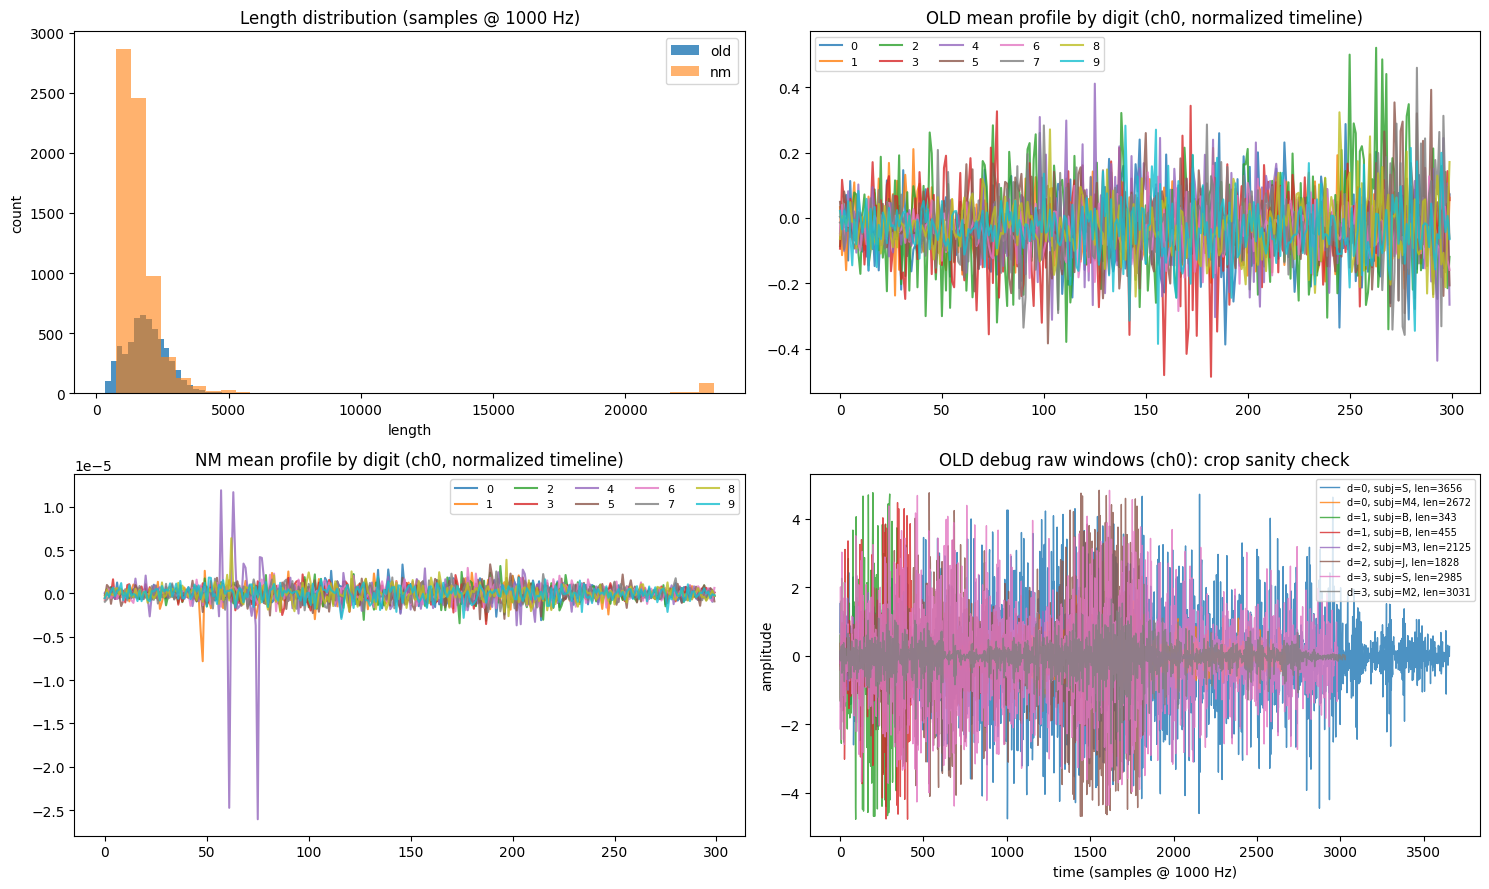

Saved QC figure: code_bobr_678/reports/artifacts/preprocessing/preprocess_varlen_qc.png
Saved QC report: code_bobr_678/reports/artifacts/preprocessing/preprocess_qc_report_varlen.json
OLD debug examples shown (digit, subject, length):
  idx=497, digit=0, subject=S, len=3656
  idx=3918, digit=0, subject=M4, len=2672
  idx=1986, digit=1, subject=B, len=343
  idx=1983, digit=1, subject=B, len=455
  idx=3507, digit=2, subject=M3, len=2125
  idx=147, digit=2, subject=J, len=1828
  idx=649, digit=3, subject=S, len=2985
  idx=3021, digit=3, subject=M2, len=3031


In [6]:
def mean_profile_by_digit(packed, digit, ch=0, points=300, max_n=80):
    tgt = packed['target']
    off = packed['offsets']
    emg = packed['emg_concat']
    idx = np.where(tgt == digit)[0][:max_n]
    if len(idx) == 0:
        return None
    dst_t = np.linspace(0.0, 1.0, points)
    rows = []
    for i in idx:
        s, e = int(off[i]), int(off[i + 1])
        x = emg[s:e, ch]
        if len(x) < 2:
            continue
        src_t = np.linspace(0.0, 1.0, len(x))
        rows.append(np.interp(dst_t, src_t, x))
    if not rows:
        return None
    return np.mean(np.stack(rows, axis=0), axis=0)


def sample_examples_by_digits(packed, digits=(0, 1, 2, 3), per_digit=2, seed=42):
    rng = np.random.default_rng(seed)
    out = []
    tgt = packed['target']
    for d in digits:
        idx = np.where(tgt == d)[0]
        if len(idx) == 0:
            continue
        take = min(per_digit, len(idx))
        picked = rng.choice(idx, size=take, replace=False)
        out.extend(int(i) for i in picked)
    return out


fig, axes = plt.subplots(2, 2, figsize=(15, 9))

# A) Length distributions
axes[0, 0].hist(old_packed['lengths'], bins=40, alpha=0.8, label='old')
axes[0, 0].hist(nm16_packed['lengths'], bins=40, alpha=0.6, label='nm')
axes[0, 0].set_title('Length distribution (samples @ 1000 Hz)')
axes[0, 0].set_xlabel('length')
axes[0, 0].set_ylabel('count')
axes[0, 0].legend()

# B) Mean profile by digit: old
for d in range(10):
    mp = mean_profile_by_digit(old_packed, d, ch=0)
    if mp is not None:
        axes[0, 1].plot(mp, label=str(d), alpha=0.8)
axes[0, 1].set_title('OLD mean profile by digit (ch0, normalized timeline)')
axes[0, 1].legend(ncol=5, fontsize=8)

# C) Mean profile by digit: nm
for d in range(10):
    mp = mean_profile_by_digit(nm16_packed, d, ch=0)
    if mp is not None:
        axes[1, 0].plot(mp, label=str(d), alpha=0.8)
axes[1, 0].set_title('NM mean profile by digit (ch0, normalized timeline)')
axes[1, 0].legend(ncol=5, fontsize=8)

# D) OLD debug raw examples: several digits with subject/length labels
example_ids = sample_examples_by_digits(old_packed, digits=(0, 1, 2, 3), per_digit=2, seed=42)
off = old_packed['offsets']
emg = old_packed['emg_concat']
tgt = old_packed['target']
subj = old_packed['subject']
for i in example_ids:
    s, e = int(off[i]), int(off[i + 1])
    x = emg[s:e, 0]
    label = f"d={int(tgt[i])}, subj={subj[i]}, len={len(x)}"
    axes[1, 1].plot(x, alpha=0.8, linewidth=1.0, label=label)
axes[1, 1].set_title('OLD debug raw windows (ch0): crop sanity check')
axes[1, 1].set_xlabel('time (samples @ 1000 Hz)')
axes[1, 1].set_ylabel('amplitude')
if len(example_ids) > 0:
    axes[1, 1].legend(fontsize=7, ncol=1)

fig.tight_layout()
qc_fig = ART_REP / 'preprocess_varlen_qc.png'
fig.savefig(qc_fig, dpi=150)
plt.show()

report = {
    'old_npz': str(OLD_NPZ),
    'nm16_npz': str(NM16_NPZ),
    'nm8_npz': str(NM8_NPZ),
    'nm_8selected_channels': idx8.tolist(),
    'old_length_stats': summarize_lengths(old_packed['lengths']),
    'nm16_length_stats': summarize_lengths(nm16_packed['lengths']),
    'nm8_length_stats': summarize_lengths(nm8_packed['lengths']),
    'old_debug_example_count': len(example_ids),
}
report_path = ART_REP / 'preprocess_qc_report_varlen.json'
report_path.write_text(json.dumps(report, indent=2, ensure_ascii=False), encoding='utf-8')
print('Saved QC figure:', qc_fig)
print('Saved QC report:', report_path)
print('OLD debug examples shown (digit, subject, length):')
for i in example_ids:
    s, e = int(off[i]), int(off[i + 1])
    print(f"  idx={i}, digit={int(tgt[i])}, subject={subj[i]}, len={e - s}")
